In [24]:
import scanpy as sc 
import pandas as pd 
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import napari
import os

import shutil
from glob import glob

In [ ]:
%load_ext autoreload
%autoreload 2

import sys 
sys.path.append('../src')

In [ ]:
img_dir = '/Volumes/Lord/LabUsers/Dmytro/20260612T110711_pa_BMP4_G3_44hr_addl_patterns/'
img_name = 'HAND1_Brachyury_mid_+.tif'
channel_names = ['HAND1', 'BMP4', 'T', 'Hoechst']

path = img_dir + img_name

dest = os.path.join('../data/downloads', img_name)
shutil.copy(path, dest)


'../data/downloads/pA_Activin_D4_power_vs_time.tif'

## Stitch and segment

In [27]:
img = tiff.imread(dest)
img_name = os.path.basename(dest)
img.shape

(4, 10064, 10064)

In [28]:
from tools.restitch_fovs import detect_grid, measure_h_seams, measure_v_seams, robust_global, restitch_channel

FOV_SIZE = 2000        # nominal size of each square FOV, in pixels
REF_CHANNEL = 3        # channel used to compute alignment
BAND = 150             # width (px) of the band used for phase correlation
OUTLIER_TOL = 10       # px: how far a seam's local estimate can be from
                       # the global median before we discard it as unreliable
BLEND_WIDTH = 20       # width (px) of the feathered blend zone

n_channels, h, w = img.shape
n_rows, n_cols = detect_grid((h, w), FOV_SIZE)
print(f"Detected grid: {n_rows} rows x {n_cols} cols of {FOV_SIZE}px FOVs")

Detected grid: 5 rows x 5 cols of 2000px FOVs


In [7]:
ref_img = img[REF_CHANNEL].astype(np.float32)
h_seams = measure_h_seams(ref_img, n_rows, n_cols, FOV_SIZE, BAND)
v_seams = measure_v_seams(ref_img, n_rows, n_cols, FOV_SIZE, BAND)

global_dx = robust_global([-dx for (_, dy, dx) in h_seams], OUTLIER_TOL)
global_dy = robust_global([-dy for (_, dy, dx) in v_seams], OUTLIER_TOL)
print(f"Global horizontal overlap estimate: {global_dx:.1f} px")
print(f"Global vertical overlap estimate:   {global_dy:.1f} px")

Global horizontal overlap estimate: 21.1 px
Global vertical overlap estimate:   19.2 px


In [8]:
overlap_x = int(round(global_dx))
overlap_y = int(round(global_dy))

out_channels = []
for c in range(n_channels):
    print(f"Restitching channel {c}...")
    out_channels.append(
        restitch_channel(img[c], n_rows, n_cols, FOV_SIZE, overlap_x, overlap_y)
    )
out = np.stack(out_channels, axis=0)

Restitching channel 0...
Restitching channel 1...
Restitching channel 2...
Restitching channel 3...


In [9]:
viewer = napari.Viewer()
_ = viewer.add_image(
    out,
    channel_axis=0, 
    name=channel_names, 
    colormap=['blue', 'green', 'red', 'magenta'],
    blending='additive'
)


In [10]:
from cellpose import models

model = models.CellposeModel(
    model_type='nuclei', 
    # model_type='cyto3',
    gpu=True
)

masks, flows, styles = model.eval(
    out, 
    channels=[4, 0], 
    channel_axis=0,
    diameter=None,
    cellprob_threshold=-3,
    flow_threshold=0.5,
    normalize={"tile_norm_blocksize": 100}
)

/opt/anaconda3/envs/latte/lib/python3.11/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
more than 65535 masks in image, masks returned as np.uint32


In [11]:
_ = viewer.add_image(masks, name='Cellpose Masks')


In [10]:
tiff.imwrite(os.path.join('../data/stitched', img_name), out)
np.save(f'../data/stitched/{img_name}.npy', masks)
out.shape, masks.shape

((4, 5958, 7943), (5958, 7943))

## Create cell features and examine segmentation quality

Extract one row per cell from the masks: shape/morphology descriptors (area, circularity, etc.)
and per-channel marker intensity (mean + sum), indexed by `cell_id` (the mask label) with
`centroid_y`/`centroid_x` kept alongside for spatial graph construction.

In [5]:
out = tiff.imread(os.path.join('../data/stitched', img_name))
masks = np.load(f'../data/stitched/{img_name}.npy')
out.shape, masks.shape

((4, 5958, 7943), (5958, 7943))

In [6]:
viewer = napari.Viewer()
_ = viewer.add_image(
    out,
    channel_axis=0, 
    name=channel_names, 
    colormap=['blue', 'green', 'red', 'magenta'],
    blending='additive'
)


In [7]:
masks.max()

np.uint32(102265)

In [8]:
from tools.qc import plot_flagged_crops, plot_feature_histograms, plot_density_map, flag_outlier_bins, crop_region
from tools.features import extract_cell_features, filter_cells

cell_df = extract_cell_features(out, masks, channel_names=channel_names)
cell_df.to_parquet(f'../data/stitched/{img_name}_features.parquet')

print(cell_df.shape)
cell_df.head()

(102265, 18)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,orientation,equivalent_diameter,circularity,aspect_ratio,HAND1_mean,BMP4_mean,T_mean,Hoechst_mean
cell_id,,,,,,,,,,,,,,,,,,
1,10.848039,435.923203,612.0,98.662951,96.416209,0.800231,0.948837,0.809524,36.529343,21.906354,1.480949,27.914559,0.827296,1.667523,171.890523,114.013072,203.991830,479.598039
2,10.825397,3754.952381,315.0,69.213203,68.299749,0.641427,0.934718,0.753589,23.400506,17.952500,-0.493996,20.026744,0.848559,1.303468,190.577778,113.365079,177.511111,582.238095
3,7.522222,5936.959259,270.0,64.142136,63.492075,0.825511,0.954064,0.838509,25.049870,14.137784,1.433873,18.541162,0.841656,1.771839,187.370370,112.544444,196.588889,585.100000
4,15.574257,6088.601132,707.0,103.112698,100.438485,0.524150,0.941411,0.786429,32.965835,28.074570,0.850873,30.003006,0.880702,1.174224,230.970297,125.469590,186.476662,871.589816
5,13.125858,14.121281,437.0,84.769553,83.048092,0.869907,0.931770,0.646450,34.079963,16.808752,0.846422,23.588253,0.796218,2.027513,205.668192,114.894737,197.032037,527.480549


flag
high_density    28
low_density     27
Name: count, dtype: int64


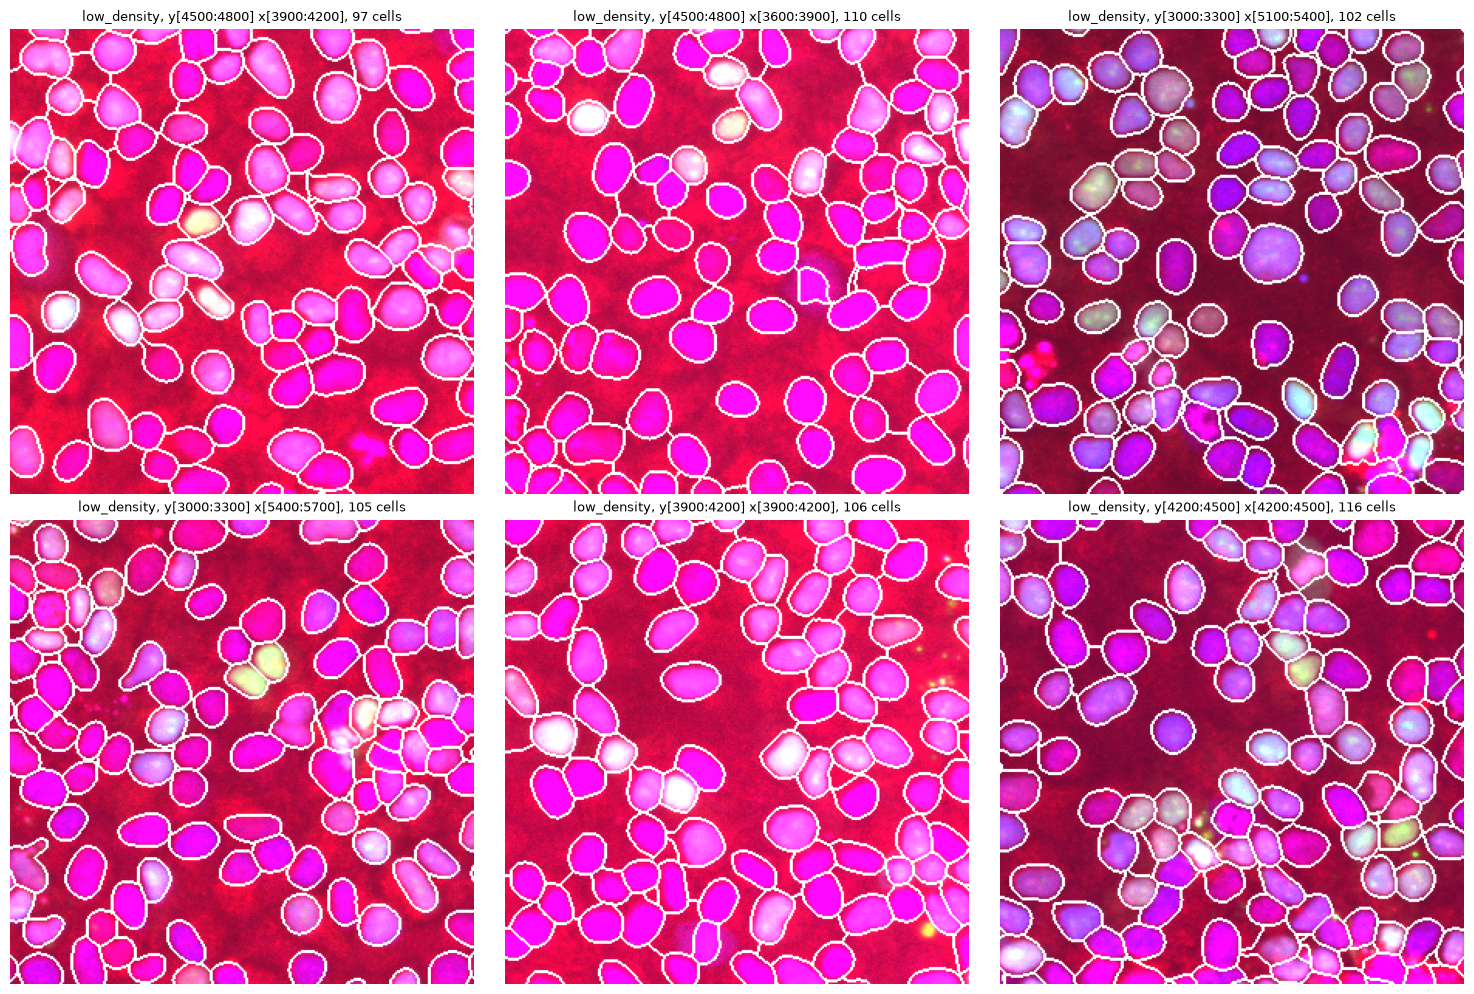

In [15]:
# Matplotlib grid of the worst-flagged regions -- no napari here on purpose: a second
# napari.Viewer() alongside the whole-mosaic one (already holding the full image +
# a 100k+-label mask, plus whatever GPU memory cellpose left resident) is what was
# crashing the kernel. This is also just better for paging through several flagged
# regions at once instead of one Viewer per row -- increase `n` to see more.

# Bins whose cell density (normalized by actual pixel area, so edge bins aren't
# falsely flagged) is a low/high outlier vs. the rest of the image -- worst first.
flagged = flag_outlier_bins(cell_df, out.shape[1:], bin_size=300)
print(flagged['flag'].value_counts())
flagged.head(10)

plot_flagged_crops(out, masks, flagged, colors=['blue', 'green', 'red', 'magenta'], n=6);

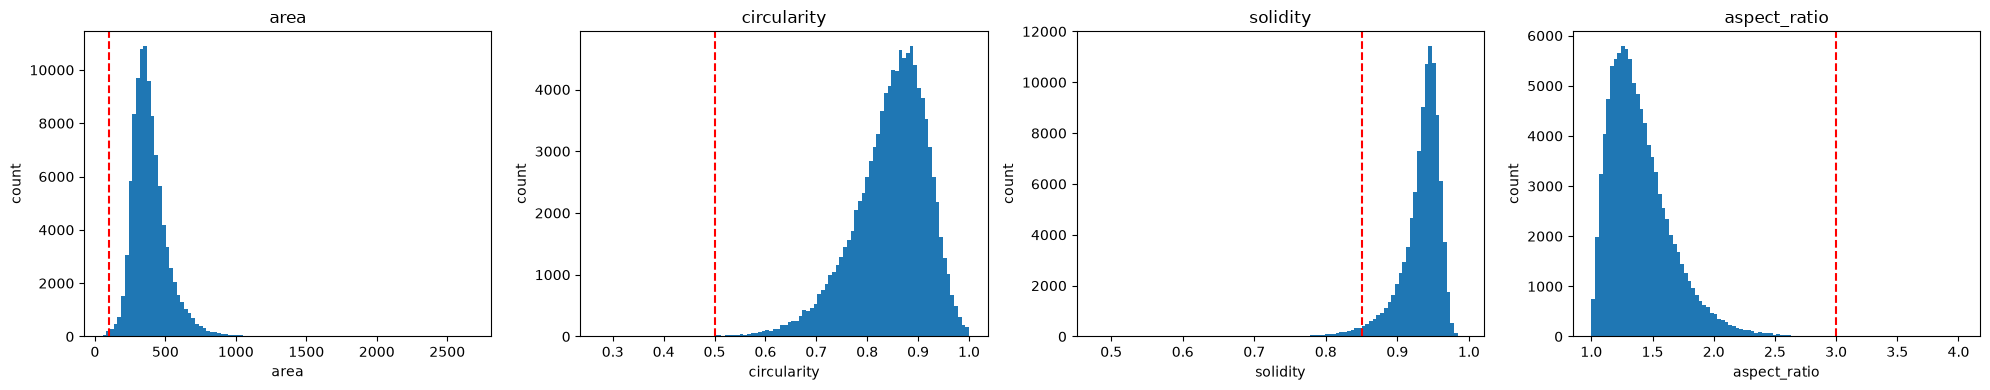

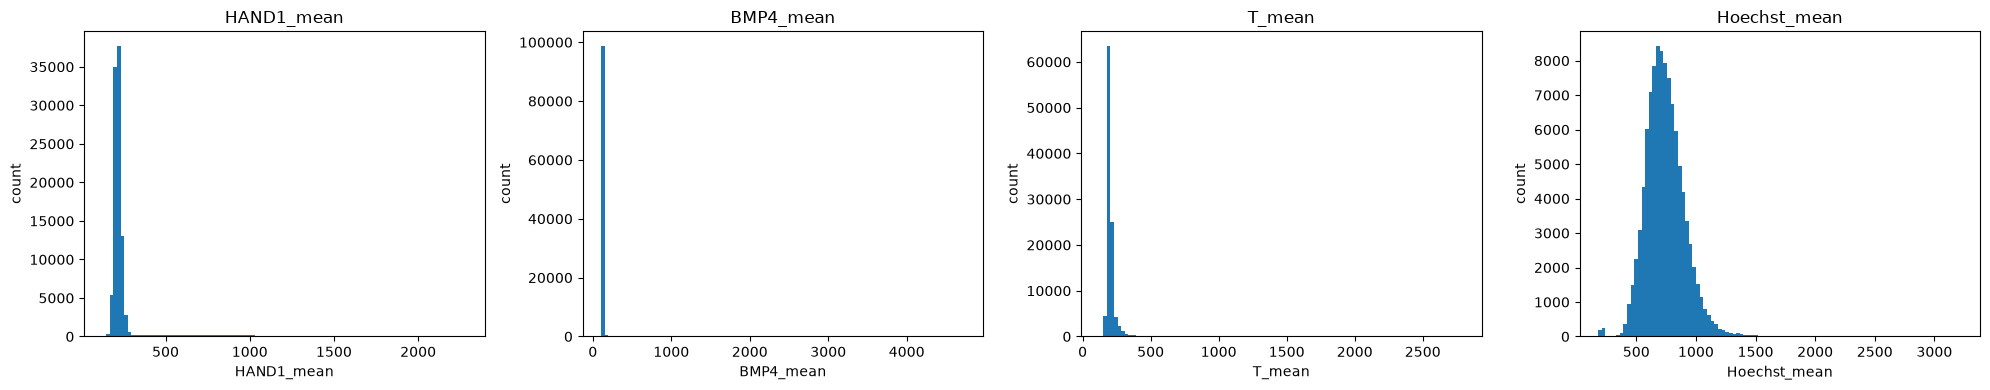

In [9]:
# Spikes near 0 = noise/fragments; a heavy right tail = merged/under-segmented blobs;
# low circularity/solidity + high aspect_ratio = thin, concave "gap between cells"
# artifacts (a crescent-shaped sliver along a cell-cell boundary getting its own label).
# view_thresholds below are starting points -- eyeball where your data actually
# separates into two populations and adjust before filtering.
_ = plot_feature_histograms(
    cell_df,
    ['area', 'circularity', 'solidity', 'aspect_ratio'],
    view_thresholds={'area': 100, 'circularity': 0.5, 'solidity': 0.85, 'aspect_ratio': 3.0}
)
_ = plot_feature_histograms(
    cell_df,
    ['HAND1_mean', 'BMP4_mean', 'T_mean', 'Hoechst_mean'],
)

In [10]:
filtered_df = filter_cells(
    cell_df,
    min_thresholds={'area': 100, 'circularity': 0.5, 'solidity': 0.85},
    max_thresholds={'aspect_ratio': 3.0},
)
filtered_df.shape[0], f"{100 * filtered_df.shape[0] / cell_df.shape[0]:.1f}% kept"

(99489, '97.3% kept')

In [13]:
filtered_masks = np.where(np.isin(masks, filtered_df.index), masks, 0)
_ = viewer.add_image(filtered_masks, name='Filtered Cellpose Masks')
np.save(f'../data/stitched/{img_name}_filtered.npy', masks)

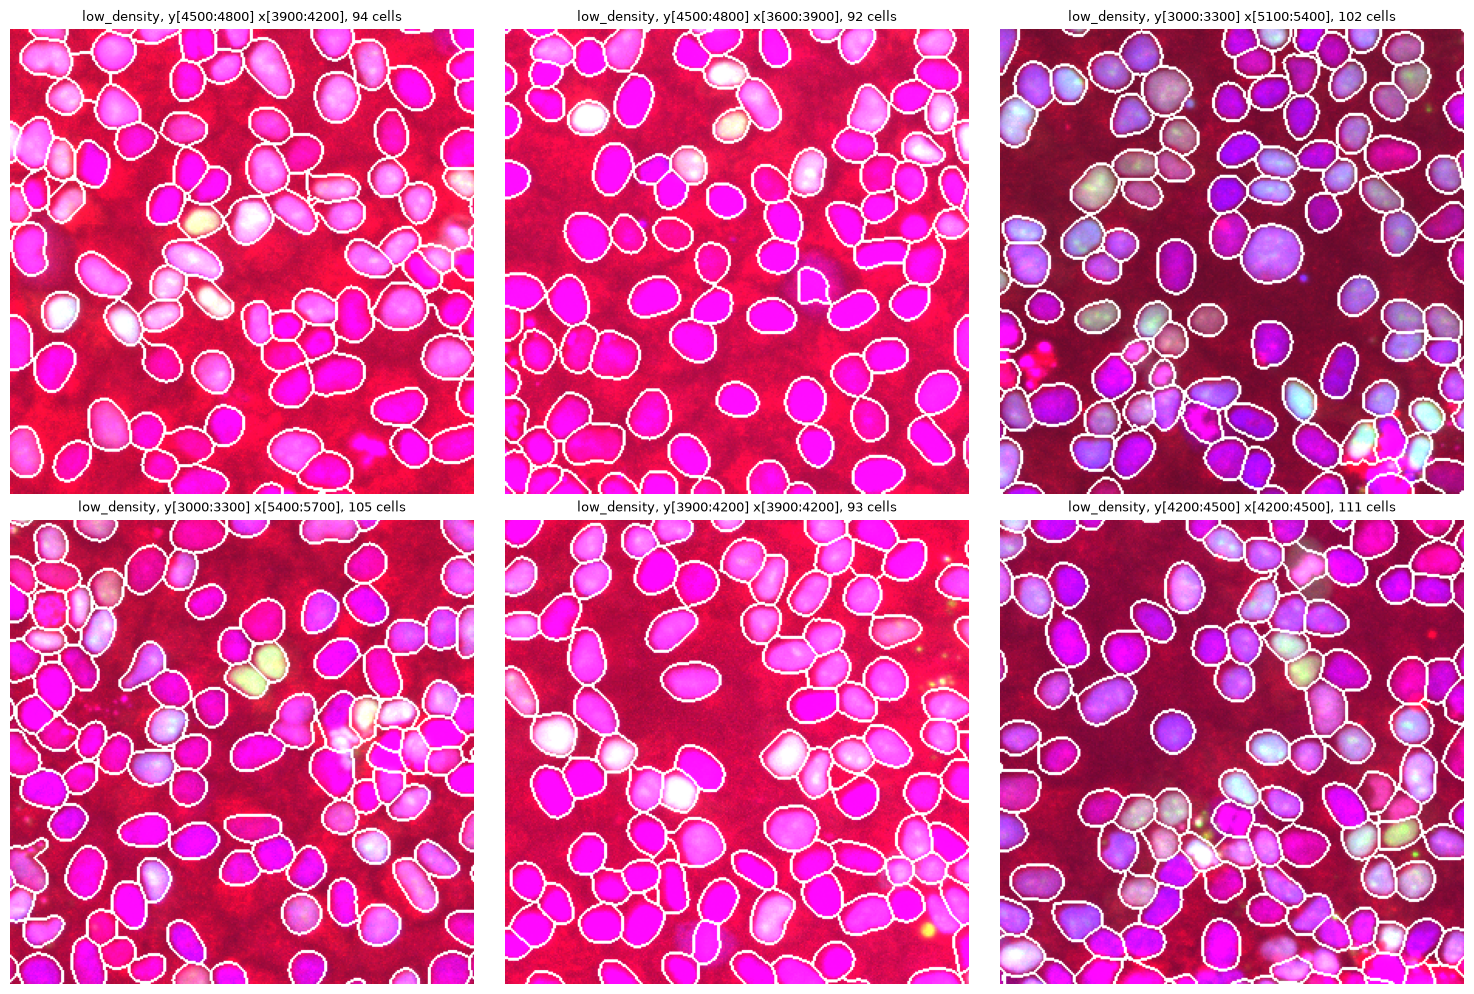

In [16]:
# flagged = flag_outlier_bins(filtered_df, out.shape[1:], bin_size=300)
# print(flagged['flag'].value_counts())
# flagged.head(10)

plot_flagged_crops(out, filtered_masks, flagged, colors=['blue', 'green', 'red', 'magenta'], n=6);

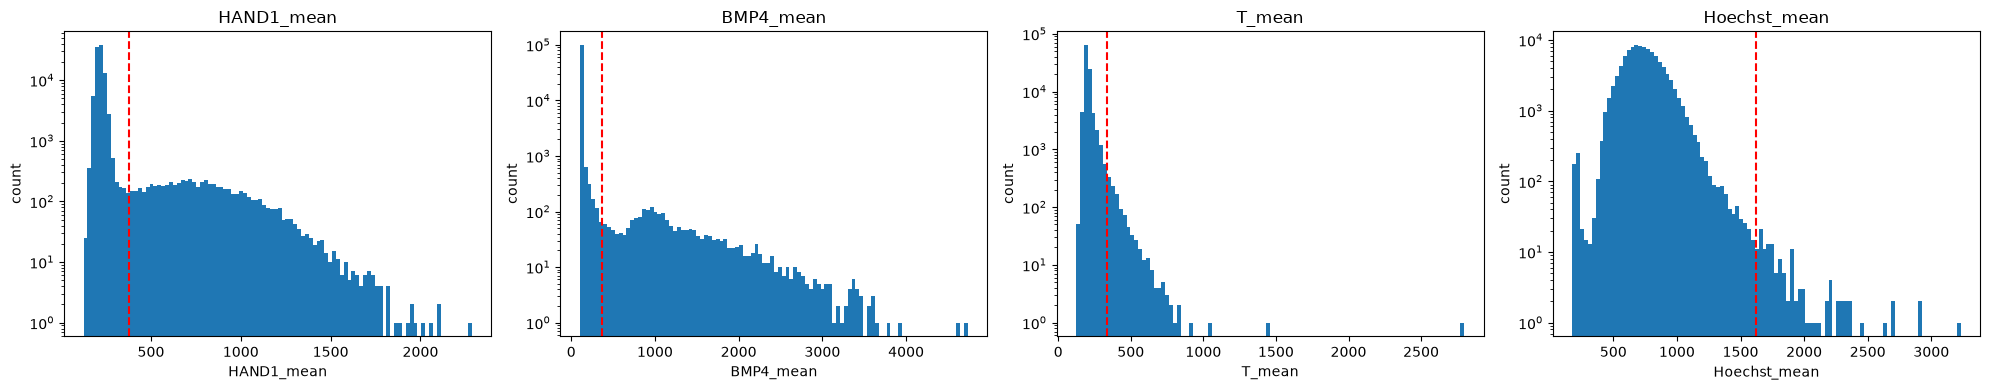

In [11]:
from tools.qc import get_bimodal_threshold
if_channels = ['HAND1_mean', 'BMP4_mean', 'T_mean', 'Hoechst_mean']
threshes = {k: get_bimodal_threshold(filtered_df, k) for k in if_channels}

_ = plot_feature_histograms(
    cell_df,
    if_channels,
    view_thresholds=threshes,
    log_scale=True
)

In [14]:
immf_masks = {}
for immf in if_channels:
    pos_name = immf.replace('_mean', '+')
    filtered_df[pos_name] = filtered_df[immf] > threshes[immf]
    pos_cells = filtered_df[filtered_df[pos_name] == True].index
    immf_masks[pos_name] = np.where(np.isin(filtered_masks, pos_cells), filtered_masks, 0)

immf_masks.keys()

dict_keys(['HAND1+', 'BMP4+', 'T+', 'Hoechst+'])

In [15]:
for immf_name, mask in immf_masks.items():
    _ = viewer.add_image(mask, name=immf_name, colormap='turbo')

In [16]:
filtered_df['Hoechst+'] = True # manually do this since it was pretty good segmentation
filtered_df.head(3)

,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,circularity,aspect_ratio,HAND1_mean,BMP4_mean,T_mean,Hoechst_mean,HAND1+,BMP4+,T+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,,
1,10.848039,435.923203,612.0,98.662951,96.416209,0.800231,0.948837,0.809524,36.529343,21.906354,...,0.827296,1.667523,171.890523,114.013072,203.991830,479.598039,False,False,False,True
2,10.825397,3754.952381,315.0,69.213203,68.299749,0.641427,0.934718,0.753589,23.400506,17.952500,...,0.848559,1.303468,190.577778,113.365079,177.511111,582.238095,False,False,False,True
3,7.522222,5936.959259,270.0,64.142136,63.492075,0.825511,0.954064,0.838509,25.049870,14.137784,...,0.841656,1.771839,187.370370,112.544444,196.588889,585.100000,False,False,False,True


In [23]:
tmp = pd.concat([filtered_df[immf].value_counts() for immf in immf_masks.keys()], axis=1)
tmp.columns = immf_masks.keys()
tmp

,HAND1+,BMP4+,T+,Hoechst+
False,92767,97290,98448,NaN
True,6722,2199,1041,99489.0


In [17]:
filtered_df.to_csv(f'../data/training/{os.path.splitext(img_name)[0]}.csv')